# Evaluación 1

**Integrante 1:** Bastián Cid

**Integrante 2:** Javiera Carrasco

**Correo Electrónico integrante 1:** bastian.cid2201@alumnos.ubiobio.cl

**Correo Electrónico integrante 2:** javiera.carrasco2201@alumnos.ubiobio.cl

**Fecha de Creación:** Abril de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 1 de la asignatura Inteligencia Artificial de la carrera de Ingeniería Civil en Informática de la Universidad del Bio Bio, sede Concepción.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

#Carga de datos

In [28]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv

--2026-04-17 01:57:32--  https://raw.githubusercontent.com/JaznaLaProfe/datos/master/preparation_data/dataset_churn_dirty.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2771759 (2.6M) [text/plain]
Saving to: ‘dataset_churn_dirty.csv.1’

dataset_churn_dirty 100%[===================>]   2.64M  --.-KB/s    in 0.07s   

2026-04-17 01:57:32 (40.7 MB/s) - ‘dataset_churn_dirty.csv.1’ saved [2771759/2771759]



In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder

In [30]:
# Cargar el set de datos para empezar a revisarlo
data = pd.read_csv('dataset_churn_dirty.csv')

In [31]:
# Cantidad de observaciones y columnas
data.shape

(21000, 16)

# Revisión de nulos

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            21000 non-null  int64  
 1   age                    19964 non-null  float64
 2   monthly_income         19962 non-null  float64
 3   tenure_months          21000 non-null  int64  
 4   num_logins_last_month  21000 non-null  int64  
 5   avg_session_time       21000 non-null  float64
 6   support_tickets        21000 non-null  int64  
 7   account_balance        21000 non-null  float64
 8   last_payment_amount    21000 non-null  float64
 9   gender                 19947 non-null  object 
 10  subscription_type      21000 non-null  object 
 11  region                 21000 non-null  object 
 12  payment_method         19953 non-null  object 
 13  is_active              21000 non-null  object 
 14  preferred_device       21000 non-null  object 
 15  ch

In [33]:
nulos = data.isnull().sum()
pd.DataFrame({'Análisis de nulos': nulos})[nulos > 0]

,Análisis de nulos
age,1036
monthly_income,1038
gender,1053
payment_method,1047


**Se identificaron cuatro columnas que presentan valores nulos, siendo estas:**

- `age`
- `monthly_income`
- `gender`
- `payment_method`



# Revisión de atípicos

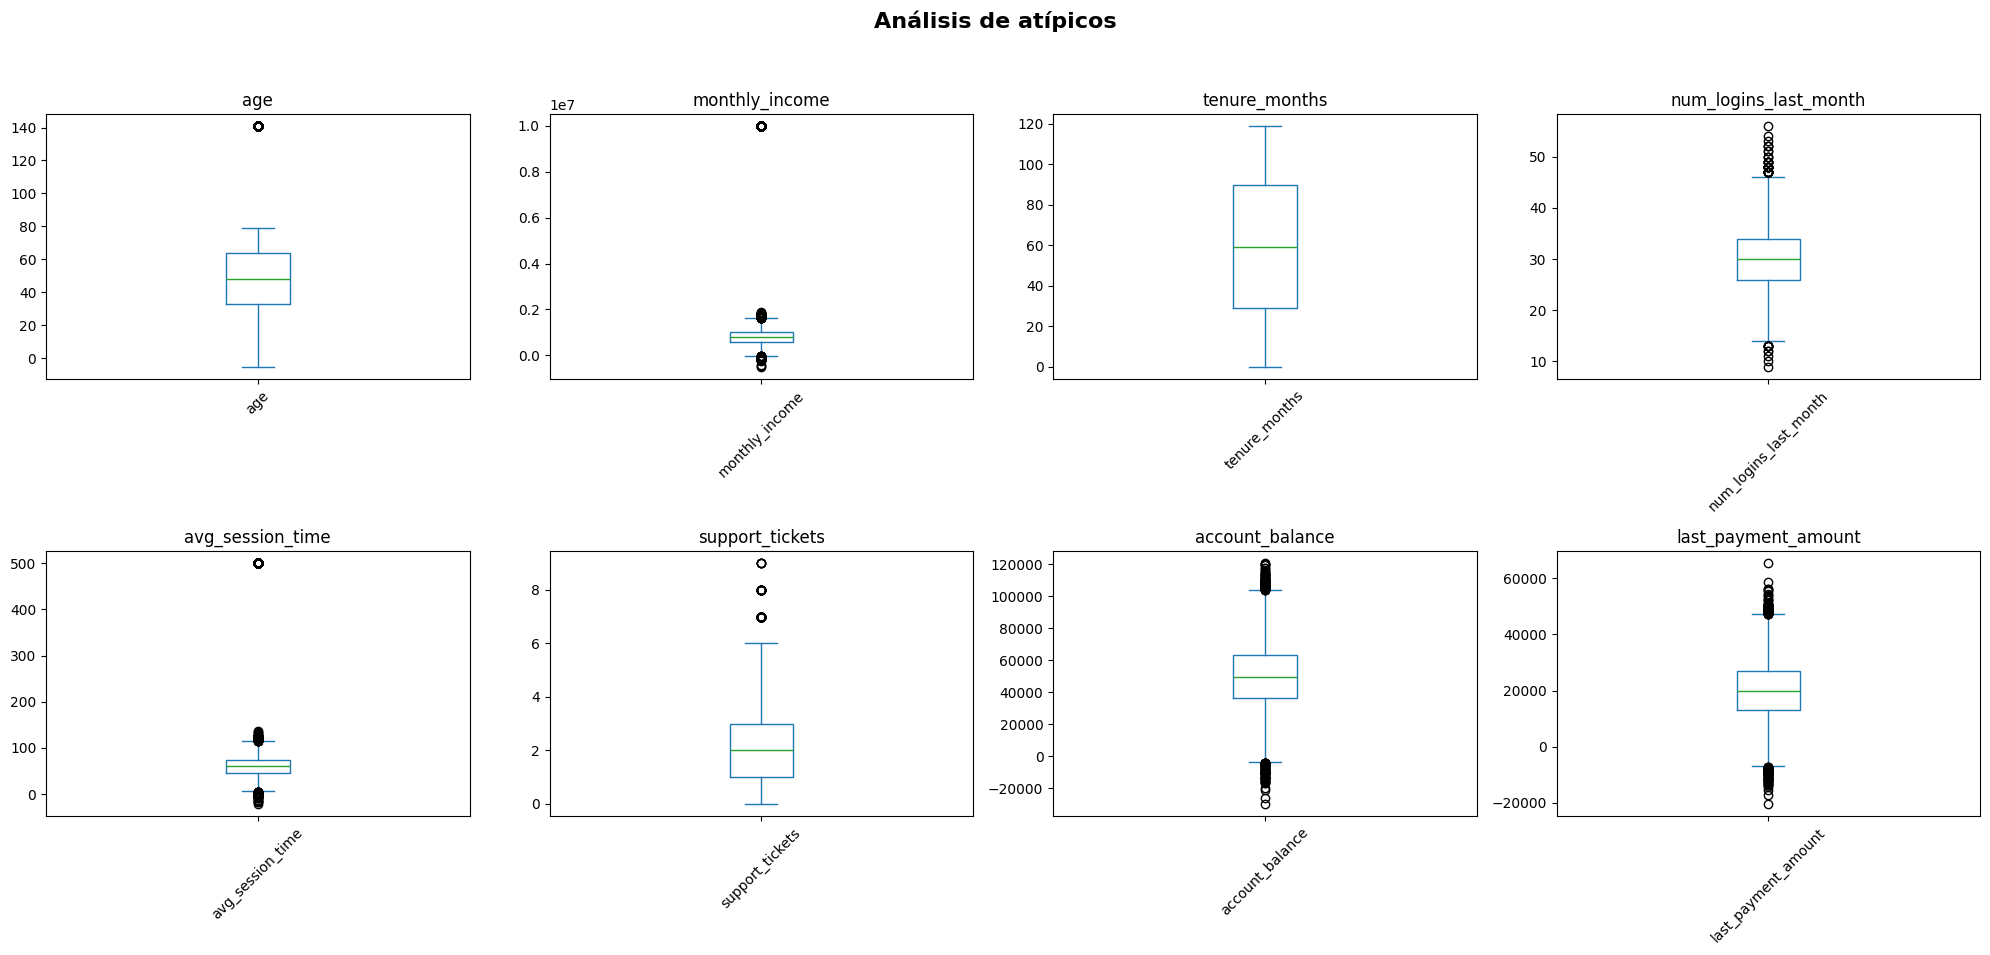

In [34]:
revision_atipicos = ['age', 'monthly_income', 'tenure_months',	'num_logins_last_month',
                     'avg_session_time', 'support_tickets', 'account_balance', 'last_payment_amount']
fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()  # convierte la matriz de ejes en un vector

for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box', ax=axes[i])
  axes[i].set_title(col)
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Se identifica lo siguiente:

- Las variables `age`, `monthly_income`, `num_logins_last_month`, `avg_session_time`, `support_tickets`, `account_balance` y `last_payment_amount` presentan valores atípicos significativos.
- La variable `tenure_months` es la única con valores dentro del rango normal.


#Revisión de inconsistencias

#     Revisión por inconsistencias cuantitativas

In [35]:
inconsistentes = data[
    (data["age"] <= 0) |
    (data["age"] >= 110) |
    (data["monthly_income"] <= 0) |
    (data["tenure_months"] < 0) |
    (data["num_logins_last_month"] < 0)]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
24,25,141.0,4.947750e+05,9,23,80.627878,2,92214.081686,37054.981204,Male,Enterprise,East,Transfer,Yes,Mobile,1
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
65,66,38.0,-1.000000e+05,81,33,55.581316,1,15548.135456,17107.203175,Other,Enterprise,North,Transfer,No,Mobile,0
98,99,-5.0,NaN,109,39,88.892528,3,43811.065972,20137.222374,Other,Basic,West,Debit Card,Yes,Desktop,0
109,110,141.0,6.252157e+05,23,33,84.661464,1,46580.838252,26496.564000,Male,Premium,East,PayPal,Yes,Tablet,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20880,3267,-5.0,1.144782e+06,42,28,72.680090,1,47537.467837,10825.074172,Female,Basic,North,PayPal,No,Desktop,0
20889,6165,24.0,-1.000000e+05,89,27,64.749148,1,43561.837005,7442.245032,Female,Enterprise,South,Debit Card,Yes,Desktop,1
20895,15830,141.0,9.751592e+05,111,27,41.043818,2,80365.789941,20325.572582,Female,Basic,East,Debit Card,No,Desktop,0
20909,2256,-5.0,4.745605e+05,22,28,57.801877,1,55557.157569,31697.060773,Other,Enterprise,North,Debit Card,No,Mobile,0


In [36]:
resumen = {
    'Edad inconsistente (<=0 o >=110)': ((data["age"] <= 0) | (data["age"] >= 110)).sum(),
    'Ingreso mensual <= 0': (data["monthly_income"] <= 0).sum(),
    'Antigüedad negativa': (data["tenure_months"] < 0).sum(),
    'Accesos negativos': (data["num_logins_last_month"] < 0).sum()
}

df_inconsistencias = pd.DataFrame.from_dict(resumen, orient='index', columns=['Cantidad de Errores'])

display(df_inconsistencias[df_inconsistencias['Cantidad de Errores'] > 0])

,Cantidad de Errores
Edad inconsistente (<=0 o >=110),422
Ingreso mensual <= 0,294


**Se identifican dos variables con valores inconsistentes:**
- `age`
- `monthly_income`

# Revisión por inconsistencias cualitativas

In [37]:
data.gender.unique()

array(['Other', nan, 'Female', 'Male'], dtype=object)

In [38]:
data.subscription_type.unique()

array(['Enterprise', 'Basic', 'Premium'], dtype=object)

In [39]:
data.region.unique()

array(['West', 'South', 'North', 'East'], dtype=object)

In [40]:
data.payment_method.unique()

array([nan, 'Debit Card', 'Credit Card', 'PayPal', 'Transfer'],
      dtype=object)

In [41]:
data.is_active.unique()

array(['Yes', 'No'], dtype=object)

In [42]:
data.preferred_device.unique()

array(['Desktop', 'Mobile', 'Tablet'], dtype=object)

**No se identifica ninguna variable cuantitativa con inconsistencias.**

#Revisión de duplicados

In [43]:
data.duplicated().sum()

np.int64(1000)

In [44]:
data[data.duplicated(keep=False)].sort_values(by='customer_id')

,customer_id,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,gender,subscription_type,region,payment_method,is_active,preferred_device,churn
29,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20808,30,49.0,8.560272e+05,75,24,24.155548,1,36786.360402,24526.064563,Other,Premium,East,PayPal,Yes,Desktop,1
20676,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
53,54,38.0,-1.000000e+05,15,28,80.815791,3,45750.504885,26898.056970,Male,Premium,East,Credit Card,Yes,Mobile,0
81,82,74.0,3.940678e+05,12,38,81.451588,2,73386.737914,15850.188316,Female,Enterprise,East,Transfer,No,Mobile,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20660,19974,33.0,1.128085e+06,111,25,87.790691,1,84751.539493,16273.962321,Male,Premium,North,Transfer,Yes,Mobile,0
20686,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19976,19977,66.0,5.620763e+05,108,43,61.314927,3,51434.870846,25963.712853,Other,Basic,North,PayPal,No,Mobile,0
19989,19990,53.0,7.261838e+05,93,29,91.552765,5,70170.793757,21619.638950,Other,Basic,West,PayPal,No,Mobile,0


**Se identifica lo siguiente:**

- Existen 1000 registros duplicados.




# Limpieza y transformación

In [45]:
# Clase para tratar atípicos (Winsorizer)
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.01, 0.01)):
        self.limits = limits
    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            self.columns_ = X.columns
        else:
            self.columns_ = np.arange(X.shape[1])
        return self
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        for col in self.columns_:
            lower = X[col].quantile(self.limits[0])
            upper = X[col].quantile(1 - self.limits[1])
            X[col] = np.clip(X[col].astype("float64"), lower, upper)
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_)

# Función para eliminar duplicados
def eliminar_duplicados(X):
    return X.drop_duplicates()

def tratar_inconsistencias(X):
    X = X.copy()

    # Inconsistencias en Edad: (<=0 o >=110)
    # Convertimos a NaN para que el Imputer los rellene después con la mediana
    X.loc[(X['age'] <= 0) | (X['age'] >= 110), 'age'] = np.nan

    # Inconsistencias en Ingreso Mensual: (<= 0)
    X.loc[X['monthly_income'] <= 0, 'monthly_income'] = np.nan

    return X


# Función para Feature Engineering
def crear_variables_adicionales(X):
    X = X.copy()
    # Ratio de tickets por mes de antigüedad
    X['tickets_por_mes'] = X['support_tickets'] / (X['tenure_months'] + 1)
    # Ratio de balance de cuenta respecto al ingreso
    X['ratio_balance_ingreso'] = X['account_balance'] / (X['monthly_income'] + 1)
    return X

In [46]:
# Variables numéricas
variables_numericas = ['age', 'monthly_income', 'tenure_months', 'num_logins_last_month',
                      'avg_session_time', 'support_tickets', 'account_balance',
                      'last_payment_amount', 'tickets_por_mes', 'ratio_balance_ingreso']

# Variables categóricas
variables_categoricas = ['gender', 'subscription_type', 'region',
                         'payment_method', 'is_active', 'preferred_device']

In [47]:
# Pipeline para Números: Trata nulos (mediana) -> Atípicos -> Escala
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('winsorizer', Winsorizer(limits=(0.01, 0.01))),
    ('scaler', StandardScaler())
])

# Pipeline para Categorías: Trata nulos (moda)
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # 'most_frequent' es la moda
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])


preprocesador = ColumnTransformer([
    ('num', pipeline_numerico, variables_numericas),
    ('cat', pipeline_categorico, variables_categoricas)
])

# Pipeline final
pipeline_final = Pipeline(steps=[
    ('limpieza_duplicados', FunctionTransformer(eliminar_duplicados)),
    ('tratar_inconsistencias', FunctionTransformer(tratar_inconsistencias)), # <-- NUEVO PASO
    ('feature_eng', FunctionTransformer(crear_variables_adicionales)),
    ('preprocesamiento', preprocesador)
])

In [48]:
data.drop(columns=['customer_id']).describe()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,churn
count,19964.000000,1.996200e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,48.763775,8.831296e+05,59.489476,29.950524,64.593725,1.999143,49991.270494,19994.073220,0.301619
std,20.781103,9.800619e+05,34.825396,5.484583,48.169755,1.411416,19927.866963,10035.594111,0.458972
min,-5.000000,-4.918861e+05,0.000000,9.000000,-20.873111,0.000000,-29809.544612,-20353.769010,0.000000
25%,33.000000,5.904548e+05,29.000000,26.000000,46.876785,1.000000,36437.872442,13248.528218,0.000000
50%,48.000000,7.989149e+05,59.000000,30.000000,60.323748,2.000000,49778.059812,19996.930030,0.000000
75%,64.000000,1.007102e+06,90.000000,34.000000,74.306634,3.000000,63433.887216,26828.259187,1.000000
max,141.000000,1.000000e+07,119.000000,56.000000,500.000000,9.000000,120775.517228,65425.194812,1.000000


In [49]:
data.describe(include="object")

,gender,subscription_type,region,payment_method,is_active,preferred_device
count,19947,21000,21000,19953,21000,21000
unique,3,3,4,4,2,3
top,Other,Enterprise,East,PayPal,Yes,Mobile
freq,6763,7039,5316,5054,10523,7089


# Guarda set de datos limpio y transformado

In [50]:

data_preparada = pipeline_final.fit_transform(data)

# Obtener nombres de columnas
cat_names = pipeline_final.named_steps['preprocesamiento'].transformers_[1][1].named_steps['encoder'].get_feature_names_out(variables_categoricas)
columnas_finales = variables_numericas + list(cat_names)

# Crear DataFrame final y exportar
df_limpio = pd.DataFrame(data_preparada, columns=columnas_finales)

In [51]:
df_limpio.head()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,tickets_por_mes,ratio_balance_ingreso,...,region_West,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet
0,-0.541886,-0.026837,0.473673,2.233157,-1.448335,-1.432223,1.073809,2.328448,-0.501298,-0.226403,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.202954,1.781558,-0.389140,-0.547780,-0.488912,0.721388,0.648309,0.621876,-0.079757,-0.491619,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,-0.018434,0.328654,0.674995,-1.289363,-0.374923,-0.714353,-0.157163,-0.466820,-0.422677,-0.404402,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.784568,-0.058535,-0.417900,-1.289363,-0.275495,-0.714353,-1.398669,2.144827,-0.357730,-0.797092,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.214211,-1.224096,1.106402,-0.176988,0.317238,0.721388,0.436214,-0.536313,-0.301173,0.980943,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [52]:
df_limpio.shape

(20000, 29)

In [53]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           20000 non-null  float64
 1   monthly_income                20000 non-null  float64
 2   tenure_months                 20000 non-null  float64
 3   num_logins_last_month         20000 non-null  float64
 4   avg_session_time              20000 non-null  float64
 5   support_tickets               20000 non-null  float64
 6   account_balance               20000 non-null  float64
 7   last_payment_amount           20000 non-null  float64
 8   tickets_por_mes               20000 non-null  float64
 9   ratio_balance_ingreso         20000 non-null  float64
 10  gender_Female                 20000 non-null  float64
 11  gender_Male                   20000 non-null  float64
 12  gender_Other                  20000 non-null  float64
 13  s

In [54]:
df_limpio.describe()

,age,monthly_income,tenure_months,num_logins_last_month,avg_session_time,support_tickets,account_balance,last_payment_amount,tickets_por_mes,ratio_balance_ingreso,...,region_West,payment_method_Credit Card,payment_method_Debit Card,payment_method_PayPal,payment_method_Transfer,is_active_No,is_active_Yes,preferred_device_Desktop,preferred_device_Mobile,preferred_device_Tablet
count,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,2.000000e+04,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000,20000.000000,20000.000000
mean,5.524470e-17,4.774847e-16,-6.394885e-18,-1.762146e-16,1.293188e-16,-5.258016e-17,7.815970e-18,5.542233e-17,6.750156e-17,9.663381e-17,...,0.252700,0.233650,0.239050,0.289450,0.237850,0.49855,0.50145,0.328950,0.336850,0.334200
std,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,1.000025e+00,...,0.434571,0.423163,0.426514,0.453518,0.425777,0.50001,0.50001,0.469844,0.472645,0.471722
min,-1.763275e+00,-2.239669e+00,-1.683359e+00,-2.216342e+00,-2.186026e+00,-1.432223e+00,-2.341307e+00,-2.397396e+00,-5.012981e-01,-1.226870e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
25%,-8.326932e-01,-6.520254e-01,-8.780669e-01,-7.331754e-01,-6.659760e-01,-7.143525e-01,-6.920550e-01,-6.829794e-01,-4.055859e-01,-5.487104e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000
50%,-1.843424e-02,-2.683668e-02,-1.525452e-02,8.407698e-03,-3.189250e-02,3.517563e-03,-1.077705e-02,2.508616e-04,-2.949187e-01,-2.264027e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.00000,0.000000,0.000000,0.000000
75%,8.539860e-01,6.008416e-01,8.763183e-01,7.499908e-01,6.221372e-01,7.213877e-01,6.872000e-01,6.933850e-01,-6.102210e-02,2.198293e-01,...,1.000000,0.000000,0.000000,1.000000,0.000000,1.00000,1.00000,1.000000,1.000000,1.000000
max,1.784568e+00,3.403129e+00,1.681610e+00,2.603949e+00,3.699351e+00,2.874998e+00,2.352358e+00,2.328448e+00,6.102841e+00,5.582981e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000,1.000000


# Comentarios finales


*   Duplicados: En caso de tratamiento duplicados, estos se eliminan.
*   Nulos: En caso de tratamiento de nulos, en estos se usa la mediana para variables numéricas y la moda para las variables categóricas.


*   Valores Atípicos: En caso de valores atípicos, se calculan fronteras y se cambian los valores que son demasiado altos o demasiado bajos por el valor de la frontera superior o inferior.
*   Inconsistencias: En caso de inconsistencias, se identifican los valores fuera de los rangos lógicos y se convierten en nulos, para posteriormente usar la moda o la mediana.



